---
title: "Taxis"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** NYC Taxi Trips
- **description:** Individual New York City taxi trips from February–March 2019, with times, fares, distances, and pickup/drop-off zones.
- **provenance:** New York City Taxi & Limousine Commission (TLC) trip-record data.
- **format:** long / tidy — 6,433 rows x 14 columns.

**Data dictionary**

- `pickup`, `dropoff` — *(identifier)* trip start and end timestamps.
- `passengers` — *(measurement)* number of passengers.
- `distance` — *(measurement)* trip distance in miles.
- `fare`, `tip`, `tolls`, `total` — *(measurement)* charge components, in US dollars.
- `color` — *(identifier)* `yellow` or `green` cab.
- `payment` — *(identifier)* `cash` or `credit card`.
- `pickup_zone`, `dropoff_zone` — *(identifier)* named TLC taxi zones.
- `pickup_borough`, `dropoff_borough` — *(identifier)* NYC borough.

**Structure**

- **Rows:** 6,433 — one row per trip.
- **Columns:** 14.
- **Identifiers:** `color`, `payment`, zone and borough columns, timestamps.
- **Measurements:** `passengers`, `distance`, `fare`, `tip`, `tolls`, `total`.

**Use cases**

- network diagrams of zone-to-zone flows
- alluvial and flow diagrams (à la Minard)
- borough- and zone-level fare aggregation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

## Long form (tidy)

In [2]:
taxis = sns.load_dataset('taxis')
taxis.info()
taxis

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


**Analytical columns**

In [94]:
taxis['tip_pct'] = taxis['tip'] / taxis['total']
taxis['pickup_hour'] = taxis.pickup.dt.hour
taxis['dropoff_hour'] = taxis.dropoff.dt.hour
taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,tip_pct,pickup_hour,dropoff_hour
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,0.166023,20,20
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,0.000000,16,16
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,0.166667,17,18
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,0.166441,1,1
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,0.082090,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan,0.166667,9,9
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx,0.000000,17,18
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn,0.000000,22,23
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn,0.000000,10,10


**Column groups**

In [96]:
taxis_places1 = ['pickup_zone', 'dropoff_zone']
taxis_places2 = ['pickup_borough', 'dropoff_borough']
taxis_times = ['pickup', 'dropoff', 'pickup_hour', 'dropoff_hour']
taxis_nominals = ['color', 'payment']
taxis_measures = ['passengers', 'distance', 'fare', 'tip', 'tip_pct', 'tolls', 'total']

## Long form aggregated by two nominals

In [97]:
taxis1 = taxis.groupby(taxis_places1)[taxis_measures].mean().sort_values('total', ascending=False)
taxis1['n'] = taxis.value_counts(taxis_places1)
taxis1.sort_values('n', ascending=False)

,,passengers,distance,fare,tip,tip_pct,tolls,total,n
pickup_zone,dropoff_zone,,,,,,,,
Upper East Side North,Upper East Side North,1.763158,0.571579,4.684211,1.074211,0.105758,0.0,9.295263,38
Upper East Side South,Upper East Side North,1.533333,1.141667,6.816667,1.490667,0.118403,0.0,11.840667,30
Astoria,Astoria,1.166667,0.748750,5.083333,0.557500,0.064108,0.0,6.878333,24
Upper East Side North,Upper East Side South,1.086957,0.983478,6.565217,1.582609,0.126525,0.0,11.828261,23
Central Harlem,Central Harlem North,1.200000,1.157500,6.525000,0.499000,0.052904,0.0,8.334000,20
...,...,...,...,...,...,...,...,...,...
Upper West Side South,Union Sq,1.000000,3.600000,16.500000,2.000000,0.089686,0.0,22.300000,1
Battery Park City,Midtown South,1.000000,4.090000,19.000000,0.000000,0.000000,0.0,22.300000,1
Two Bridges/Seward Park,East Harlem South,2.000000,5.900000,19.000000,0.000000,0.000000,0.0,22.300000,1


In [98]:
taxis2 = taxis.groupby(taxis_places2)[taxis_measures].mean().sort_values('total', ascending=False)
taxis2['n'] = taxis.value_counts(taxis_places2)
taxis2.sort_values('n', ascending=False)

passengers   distance       fare        tip  \
pickup_borough dropoff_borough                                                
Manhattan      Manhattan          1.569089   1.855879   9.727019   1.761994   
Queens         Queens             1.467049   3.157765  12.812178   0.843782   
Brooklyn       Brooklyn           1.262411   2.510780  11.877589   0.629362   
Queens         Manhattan          1.558036  11.968884  36.923839   6.194330   
Manhattan      Queens             1.668712  10.976748  34.623804   5.904663   
               Brooklyn           1.477124   6.669608  24.495098   3.402026   
Brooklyn       Manhattan          1.507463   6.950597  25.096567   2.331493   
Bronx          Bronx              1.272727   3.677273  14.539091   0.095758   
Queens         Brooklyn           1.709677  11.884194  37.018871   4.145806   
Manhattan      Bronx              1.290909   6.948727  24.127273   0.891818   
Brooklyn       Queens             1.346154  10.874615  34.842692   1.400769   
Bronx          Manhattan          1.040000   8.562800  29.698000   0.335600   
Queens         Bronx              1.363636  16.636364  45.772727   1.577273   
Brooklyn       Bronx              1.400000  19.600000  58.124000   0.000000   
Bronx          Queens             1.000000  14.030000  40.157500   0.000000   
               Brooklyn           1.000000  13.492500  54.062500   0.000000   
Manhattan      Staten Island      1.000000  15.855000  44.500000  14.165000   

                                 tip_pct      tolls      total     n  
pickup_borough dropoff_borough                                        
Manhattan      Manhattan        0.109677   0.005277  14.945734  4885  
Queens         Queens           0.045974   0.134842  14.973610   349  
Brooklyn       Brooklyn         0.050701   0.000000  13.701454   282  
Queens         Manhattan        0.113153   4.424286  51.056518   224  
Manhattan      Queens           0.114724   3.413988  47.355337   163  
               Brooklyn         0.102731   0.676209  32.164183   153  
Brooklyn       Manhattan        0.084814   1.203582  31.483881    67  
Bronx          Bronx            0.008427   0.127273  15.648485    66  
Queens         Brooklyn         0.086417   0.000000  42.351774    62  
Manhattan      Bronx            0.029236   0.248727  27.082364    55  
Brooklyn       Queens           0.045449   0.000000  37.224231    26  
Bronx          Manhattan        0.006668   1.132800  31.942400    25  
Queens         Bronx            0.036079   4.985455  53.417273    11  
Brooklyn       Bronx            0.000000   5.760000  64.824000     5  
Bronx          Queens           0.000000   5.760000  46.567500     4  
               Brooklyn         0.000000   4.320000  59.032500     4  
Manhattan      Staten Island    0.183310  14.400000  76.865000     2

## Wide form 1 by 1 with counts

In [99]:
taxis3a = taxis2.n.unstack(fill_value=0)
taxis3a

dropoff_borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island
pickup_borough,,,,,
Bronx,66,4,25,4,0
Brooklyn,5,282,67,26,0
Manhattan,55,153,4885,163,2
Queens,11,62,224,349,0


In [100]:
taxis3b = taxis2['tip_pct'].unstack(fill_value=0)
taxis3b.style.format(precision=2).background_gradient(axis=None, cmap='Greens')

dropoff_borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island
pickup_borough,,,,,
Bronx,0.01,0.00,0.01,0.00,0.00
Brooklyn,0.00,0.05,0.08,0.05,0.00
Manhattan,0.03,0.10,0.11,0.11,0.18
Queens,0.04,0.09,0.11,0.05,0.00


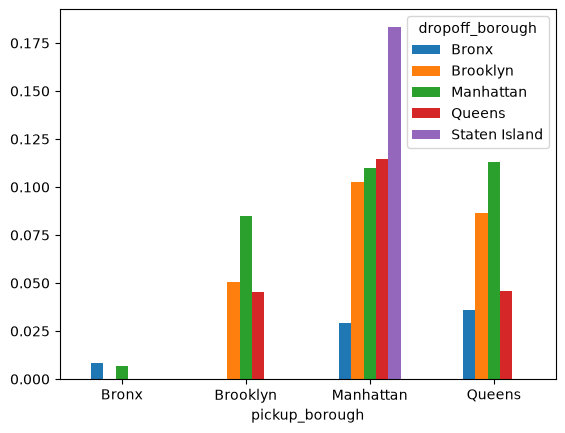

In [101]:
taxis3b.plot.bar(rot=0)
plt.show()

In [102]:
taxis_tip_hour = taxis.groupby('pickup_hour').tip_pct.mean()

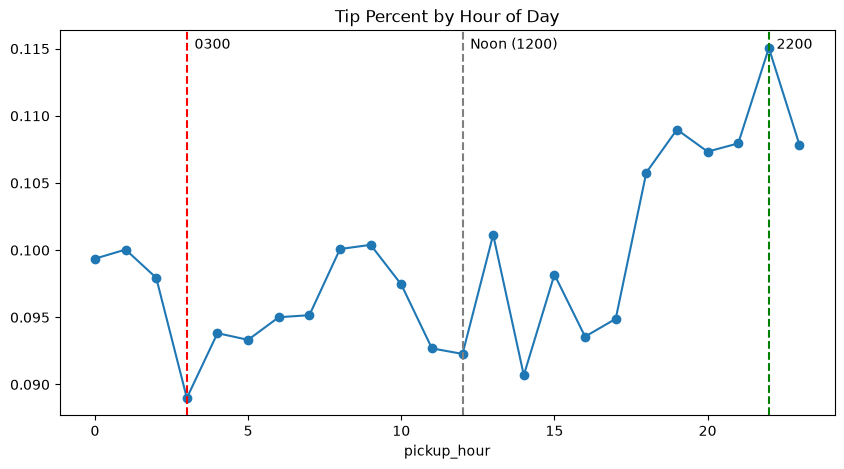

In [103]:
ax = taxis_tip_hour.plot(style='o-', figsize=(10, 5))
ax.axvline(12, ls='--', c='gray')
ax.axvline(taxis_tip_hour.idxmin(), ls='--', c='red')
ax.axvline(taxis_tip_hour.idxmax(), ls='--', c='green')
ax.text(12.25, .115, "Noon (1200)")
ax.text(taxis_tip_hour.idxmin() +.25, .115, str(taxis_tip_hour.idxmin()).zfill(2)+'00')
ax.text(taxis_tip_hour.idxmax() +.25, .115, str(taxis_tip_hour.idxmax()).zfill(2)+'00')
plt.title("Tip Percent by Hour of Day")
plt.show()